# MDT2201 - Semana 9
## Prediccion de Calidad del Vino en base a propiedades Fisico-Quimicas integrado para Evaluación Transversal

### Caso: Predicción de Calidad del Vino, con dataset de Scikit-Learn

Se trabajará con el dataset `Winequality-Red()` de Scikit-Learn. El objetivo será construir un modelo de regresión para predecir la variable `Calidad del Vino - Quality`a partir de otras propiedades fisico -químicas del vino.

La elección de `Quality` como variable objetivo permite mantener el contexto de vinos y trabajar un problema de regresión.

### Contenidos integrados

1. Formulación matricial del modelo.
2. Selección y análisis de variables.
3. Función de costo MSE.
4. Solución analítica por mínimos cuadrados.
5. Análisis de propiedades matriciales.
6. Descenso de gradiente.
7. Ajuste de tasa de aprendizaje.
8. Regularización L1 y L2.
9. PCA y varianza acumulada.
10. Comparación entre modelo original y modelo reducido.
11. Interpretación final y justificación técnica.


## 0. Preparación del entorno

En este bloque se importan las librerías necesarias. Cada bloque del notebook conecta el código con un concepto matemático de la asignatura.

In [47]:
# ================================
# 0. IMPORTACIÓN DE LIBRERÍAS
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.decomposition import PCA

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
np.random.seed(42)


## 1. Carga del dataset y definición del problema

El dataset `winequality-red()` contiene mediciones químicas de vinos. Para este ejercicio se define:

- Variable objetivo: `quality`.
- Variables predictoras: todas las demás variables químicas.

Esto permite formular un problema de regresión:

$$y = X\beta + \varepsilon$$

Donde `X` es la matriz de variables predictoras, `y` es el vector objetivo y `β` representa los parámetros del modelo.

In [48]:
## ================================
# 1. CARGA DEL DATASET
# ================================
from google.colab import files
# Subir archivo desde tu computador
uploaded=files.upload()
# Obtener nombre del archivo
file_name=list(uploaded.keys())[0]
# Leer CSV
df=pd.read_csv(file_name)

# Reemplaza la línea de lectura de punta y coma (;) por coma (,)para separar los valores:
df = pd.read_csv(file_name, sep=';')

# Mostramos las primeras filas para conocer la estructura del dataset.
display(df.head())

# Variable objetivo: quality.
y = df["quality"].values

# Variables predictoras: todas las variables excepto quality.
X = df.drop(columns=["quality"])

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)
print("Número de observaciones:", X.shape[0])
print("Número de variables predictoras:", X.shape[1])

# Verificar que se vea como tabla
#df.head()


Saving winequality-red.csv to winequality-red (4).csv


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Dimensión de X: (1599, 11)
Dimensión de y: (1599,)
Número de observaciones: 1599
Número de variables predictoras: 11


### Interpretación del bloque 1

La matriz `X` contiene las variables químicas que usará el modelo para predecir `quality`. La variable `y` contiene calidad del vino. Este bloque traduce el problema real a una estructura matemática: datos de entrada, variable objetivo y modelo predictivo.

## 2. Exploración inicial de variables

Antes de modelar, se revisa la relación entre cada predictor y la variable objetivo. Esto permite justificar técnicamente qué variables parecen relevantes para el modelo.

Correlación de cada variable con quality:


,correlación con quality
alcohol,0.476166
volatile acidity,-0.390558
sulphates,0.251397
citric acid,0.226373
total sulfur dioxide,-0.185100
density,-0.174919
chlorides,-0.128907
fixed acidity,0.124052
pH,-0.057731
free sulfur dioxide,-0.050656


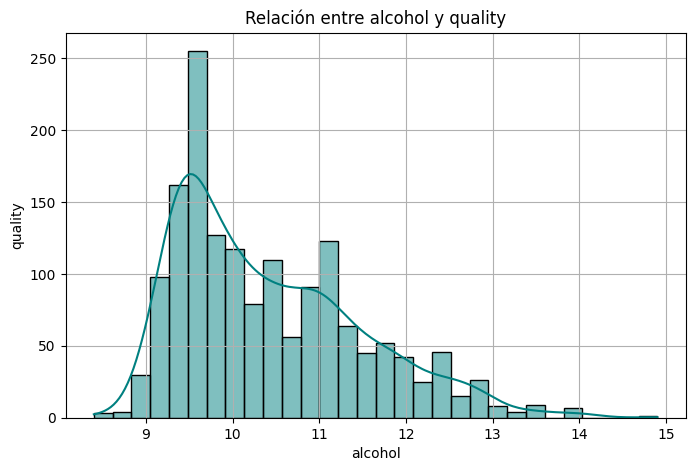

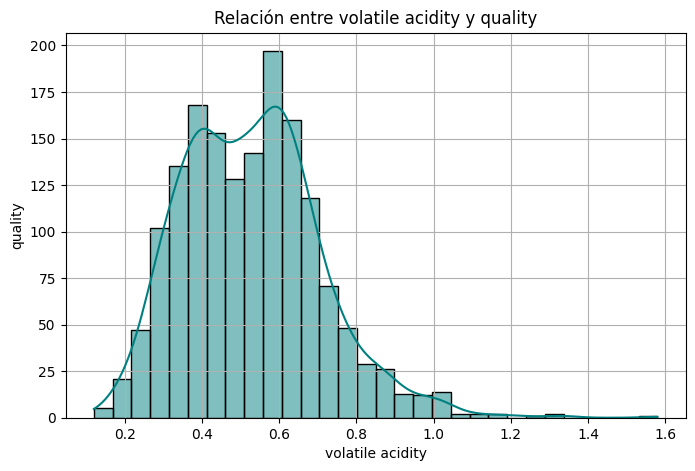

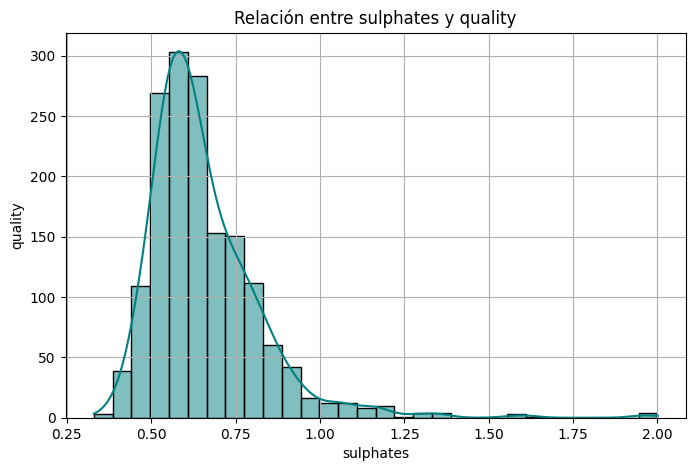

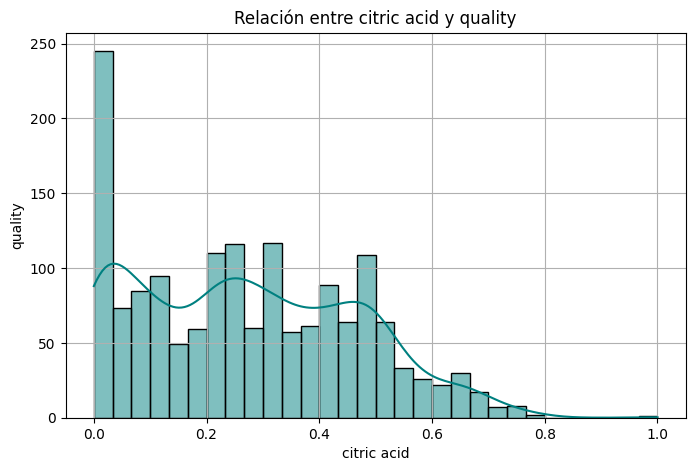

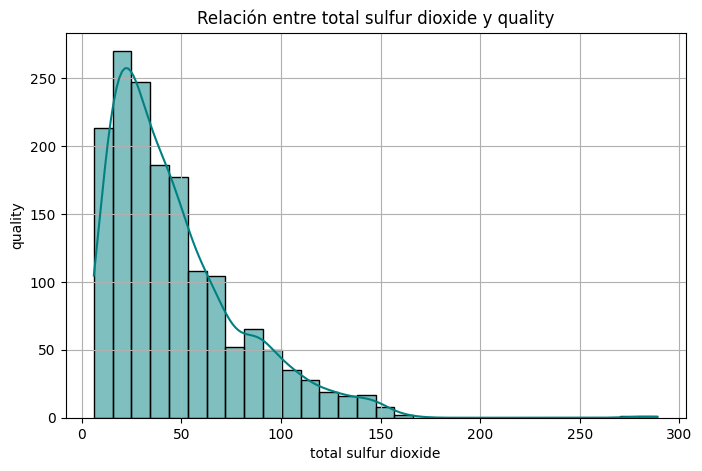

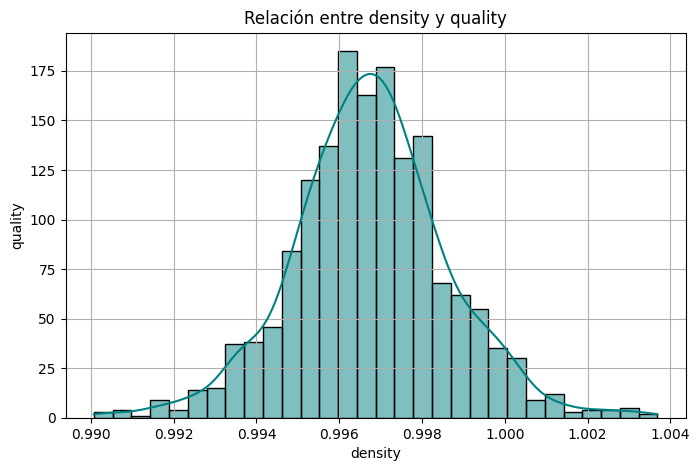

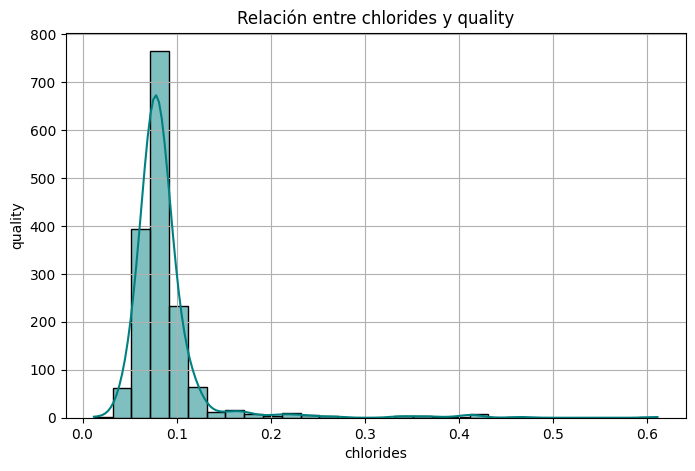

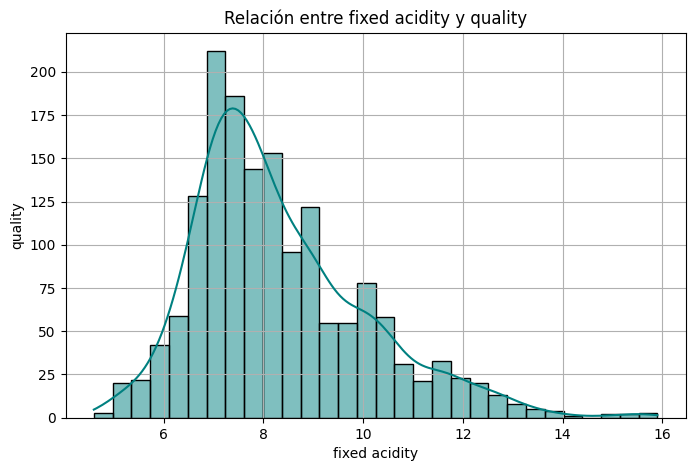

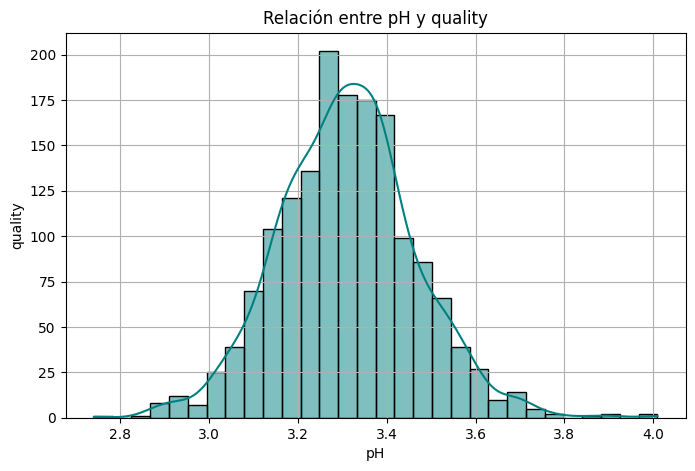

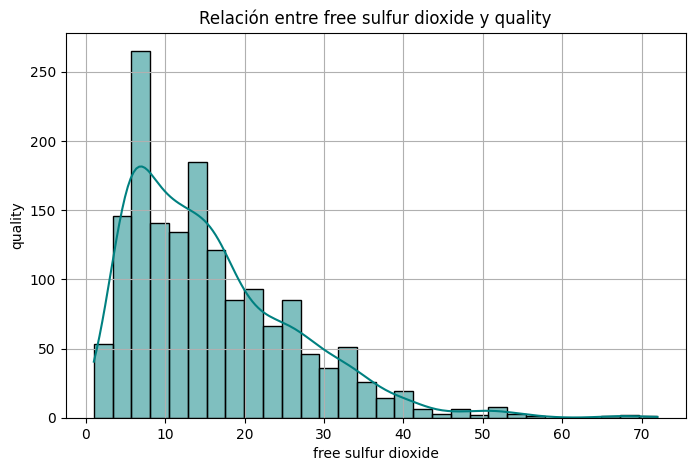

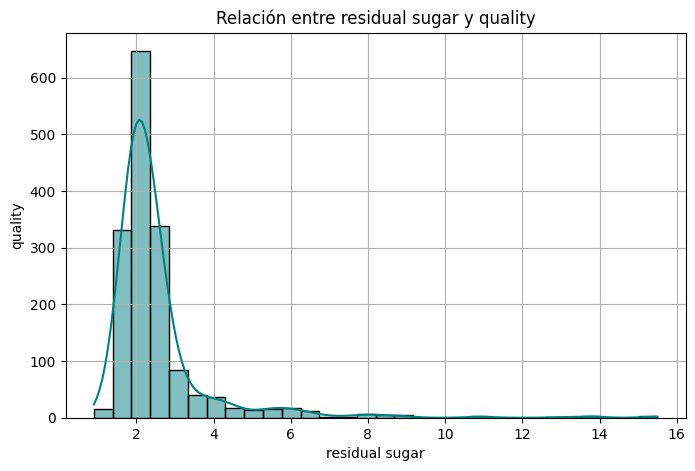

In [49]:
# ================================
# 2. EXPLORACIÓN DE VARIABLES
# ================================

correlaciones = X.copy()
correlaciones["quality"] = y

corr_quality = correlaciones.corr()["quality"].drop("quality").sort_values(key=abs, ascending=False)

print("Correlación de cada variable con quality:")
display(corr_quality.to_frame("correlación con quality"))

# Graficamos las 11 variables con mayor correlación absoluta con quality.
top_vars = corr_quality.abs().head(11).index


for col in top_vars:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=col, color='teal', bins=30, kde=True)

    plt.xlabel(col)
    plt.ylabel("quality")
    plt.title(f"Relación entre {col} y quality")
    plt.show()


Interpretacion

. Correlación Positiva Fuerte/Moderada

alcohol (0.476): Es la variable más importante de todo tu dataset. El porqué: En la industria vitivinícola, los vinos con mayor graduación alcohólica (dentro de un límite razonable) suelen tener más "cuerpo" y mejor estructura, lo que los catadores tienden a calificar con puntajes más altos.

sulphates (0.251) y citric acid (0.226): El porqué: Los sulfatos actúan como antioxidantes y antimicrobianos, manteniendo el vino fresco y evitando que se oxide. El ácido cítrico aporta "frescura" y realza los sabores. Más de esto (sin pasarse) equivale a un vino mejor conservado y más vibrante.

2. Correlación Negativa Fuerte

volatile acidity (-0.390): Esta es la segunda variable más fuerte, pero en sentido contrario. El porqué: La acidez volátil es esencialmente el nivel de ácido acético en el vino. En niveles altos, le da al vino un olor y sabor a vinagre. Por pura lógica, a más sabor a vinagre, menor puntaje de calidad.

3. Correlación Débil

total sulfur dioxide, density, chlorides (-0.12 a -0.18): Tienen un impacto negativo ligero. El porqué: Demasiado dióxido de azufre huele a fósforo quemado, y los cloruros aportan sabor salado. Un exceso de cualquiera de ellos castiga ligeramente la puntuación.

4. Correlación Nula

pH, free sulfur dioxide, residual sugar (-0.05 a 0.01): Estos valores son matemáticamente irrelevantes para predecir la calidad linealmente. El porqué: El azúcar residual (0.013) es un gran ejemplo. Hay vinos dulces excelentes y vinos secos excelentes. La cantidad de azúcar define el estilo del vino, pero no es un indicador universal de su calidad.



## Comprendiendo y reprocesando

--- Primeras filas ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



--- Información de columnas y tipos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

Valores nulos totales: 0
Filas duplicadas encontradas: 240

--- Resumen estadístico 

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


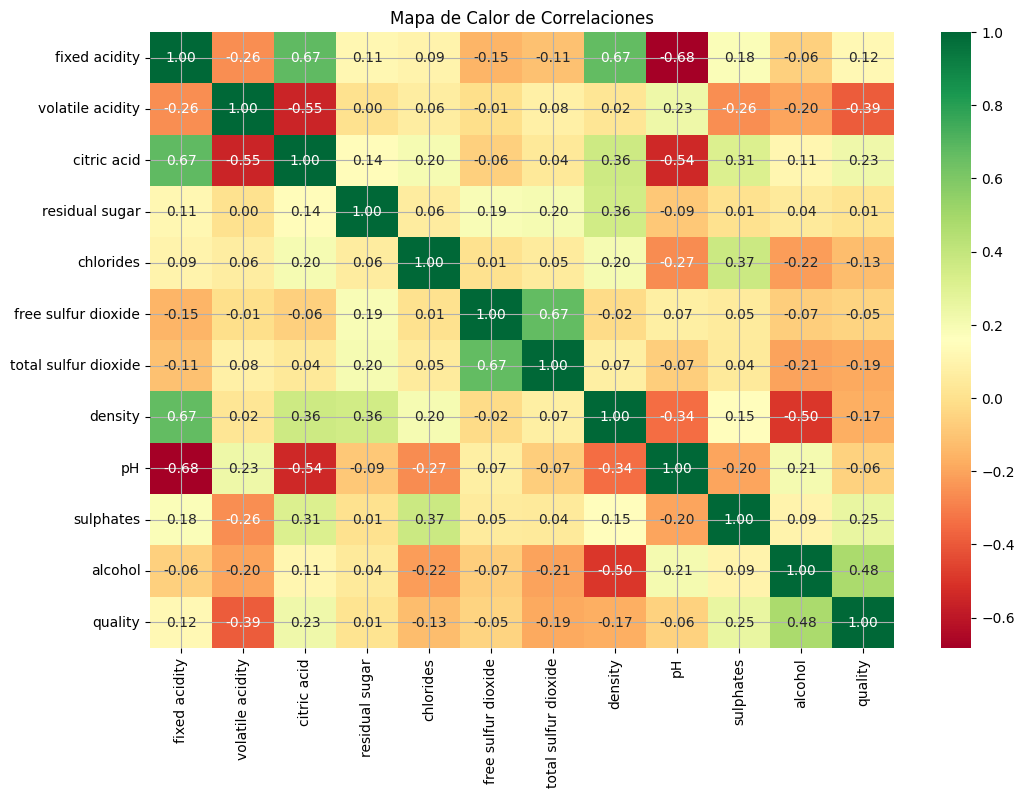

/tmp/ipykernel_4535/701047480.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='viridis')


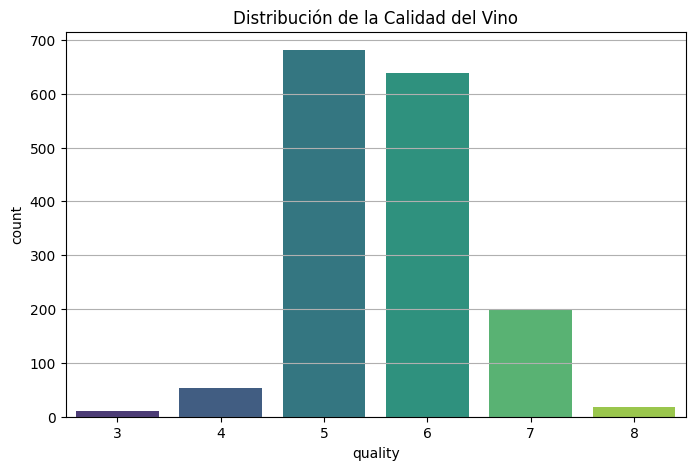

In [50]:
# 1. Inspección rápida
print("--- Primeras filas ---")
display(df.head())

print("\n--- Información de columnas y tipos ---")
df.info()

# 2. Limpieza: Revisar duplicados y nulos
print(f"\nValores nulos totales: {df.isnull().sum().sum()}")
print(f"Filas duplicadas encontradas: {df.duplicated().sum()}")

# Opcional: Eliminar duplicados si quieres datos limpios
# df = df.drop_duplicates()

# 3. Análisis Estadístico
print("\n--- Resumen estadístico ---")
display(df.describe())

# 4. Visualización: Correlación entre variables
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Mapa de Calor de Correlaciones")
plt.show()

# 5. Distribución de la Calidad (Variable Objetivo)
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=df, palette='viridis')
plt.title("Distribución de la Calidad del Vino")
plt.show()



Observaciones

1.De Inspección se indica que
1.1.Primeras filas
1.1.1. Confirmación de Duplicados

Inferencia: la fila 0 y la fila 4 son exactamente iguales en todas sus columnas.

Esto indica que el dataset tiene registros repetidos. En Ciencia de Datos, mantener duplicados puede causar "overfitting" (sobreajuste).

1.1.2.Escalas de Medición (Magnitudes)

Density: tiene valores muy pequeños y precisos (ej. 0.9978). Total sulfur dioxide: tiene valores mucho más grandes (ej. 67.0)

Inferencia:Normalizar o Escalar los datos. Dado que la columna con números más grandes "dominará" a las demás injustamente.

1.1.3.Naturaleza de la Variable Objetivo (quality)

Los valores son 5, 5, 5, 6, 5. Son números enteros.

Inferencia: Aunque parecen números, actúan como categorías ordinales. El problema es de clasificación o regresión discreta porque estamos tratando de clasificar el vino en niveles de calidad.

1.1.4.Análisis de "Citric Acid"

En las filas 0, 1 y 4, el valor es 0.00.

Inferencia: Es común que algunos vinos no tengan ácido cítrico, pero también podría ser una falta de medición en esos registros. Si el valor 0.00 se repite demasiado en todo el dataset, la variable podría tener poca varianza y ser poco útil para el modelo.

Resumen
Caracteristicas -Variables de entrada: Son las propiedades químicas (acidez, azúcares, alcohol).

Target - Objetivo: Es la etiqueta de quality asignada por expertos.

1.2.Información de columnas y tipos:
Density es un dato float64

PH es un dato float64

2.Limpieza: Revisar duplicados y nulos
No existen datos nulos

Existen 240 registros duplicados

3.Análisis Estadístico
3.1. Este Analisis se realizra una vez que se eliminen los duplicados.

4. Visualización: Correlación entre variables
Mapa de Calor
"A mayor nivel de alcohol mayor es la calidad percibida " para este caso puede existir una correlacion ".

1.Variables que más afectan la Calidad:
Alcohol (0.48): Es la correlación positiva más fuerte. Significa que, generalmente, los vinos con mayor graduación alcohólica en este dataset tienden a recibir mejores puntuaciones de calidad.

Volatile Acidity (-0.39): Tiene una correlación negativa moderada. Esto tiene sentido lógico: una acidez volátil alta suele dar un sabor avinagrado, lo que reduce la calidad.

Sulphates (0.25) y Citric Acid (0.23): Tienen una influencia positiva leve pero relevante.

2.Relaciones Fuertes entre Variables - Multicolinealidad
Fixed Acidity vs. pH (-0.68): Es una correlación negativa fuerte. A mayor acidez fija, menor es el pH (más ácido es el vino). Esto confirma que los datos tienen coherencia química.

Fixed Acidity vs. Citric Acid (0.67): Relación positiva fuerte, lo cual es esperable ya que el ácido cítrico es parte de la acidez fija.

Free Sulfur Dioxide vs. Total Sulfur Dioxide (0.67): Relación lógica, ya que el azufre libre es una parte del azufre total.

Fixed Acidity vs. Density (0.67): Indica que los ácidos contribuyen significativamente a la densidad del vino.

3.Variables "Neutras"
Residual Sugar (0.01): Sorprendentemente, el azúcar residual casi no tiene relación con la calidad en este dataset específico. No parece ser un factor determinante para los evaluadores.

Chlorides (-0.13): Tiene un impacto negativo muy bajo en la calidad.

5. Distribución de la Calidad (Variable Objetivo)
Me indica la distribucion de la calidad de los vinos

Calidad entre 5 y 6: Vinos promedios

Calidad 8 : Vinos excelentes

Calidad 3: Vinos malos

Conclusiones
1.Variables Predictoras Clave: Para el modelo de Machine Learning las variables alcohol, volatile acidity, sulphates y citric acid son las "Caracteristica" más importantes.
2.Redundancia: Dado que fixed acidity, density y citric acid están muy correlacionadas entre sí, para evitar el exceso de ruido, multicolinealidad, no se consideraran en el modelo.

Filas antes de limpiar: 1359
Filas después de limpiar: 1359



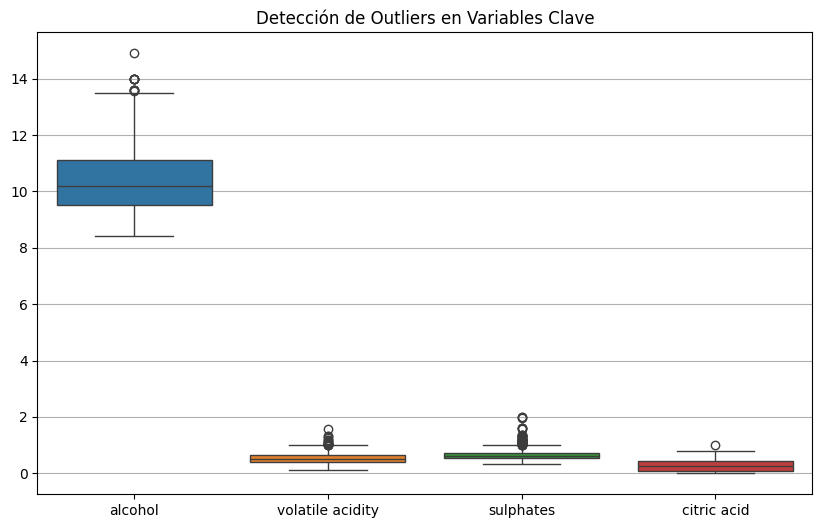

In [51]:
# Opcional: Eliminar duplicados si quieres datos limpios
df = df.drop_duplicates()

# 1. ELIMINAR DUPLICADOS
print(f"Filas antes de limpiar: {len(df)}")
df = df.drop_duplicates()
print(f"Filas después de limpiar: {len(df)}\n")

# Grafica de Los "Outliers" Persisten
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['alcohol', 'volatile acidity', 'sulphates', 'citric acid']])
plt.title("Detección de Outliers en Variables Clave")
plt.show()

##Se eliminó 240 registros duplicados, aproximadamente 15% del dataset original, pasé de 1599 a 1359 filas.

##1.Duplicados:de esta informacion al eliminar los duplicados:
1.1.La representatividad: Ahora cada fila es un experimento único. Al haber menos datos, pero más diversos, mi modelo de Machine Learning será más robustos y menos propenso a memorizar casos específicos.

1.2.Estadísticos estables: Si comparas con la tabla anterior, notarás que la media (mean) y la desviación estándar (std) apenas variaron (ej. el alcohol pasó de 10.42 a 10.43). Esto es una buena señal: indica que los duplicados estaban distribuidos de forma aleatoria y no concentrados en un solo tipo de vino.

##2.Los "Outliers" :
2.1. El problema de las escalas (Magnitud)

Lo primero que salta a la vista es que alcohol "aplasta" visualmente a las otras tres variables.

• Como el alcohol se mide en valores de 8 a 15 y las otras tres están mayormente por debajo de 2, es difícil ver la dispersión real de la acidez o los sulfatos en este mismo gráfico. Inferencia: Para un modelo de Machine Learning, esto confirma que necesit0 escalar los datos, para que el algoritmo no crea que el alcohol es "más importante" solo por tener números más grandes.

2.2. Análisis por Variable

• Alcohol (Azul) Es la variable con la caja más grande, lo que indica que hay una buena variedad de niveles de alcohol en los datos. Tiene pocos outliers y están concentrados en la parte superior (vinos con graduación muy alta, cerca del 15%). Esto sugiere que es una variable bastante estable y confiable.

• Acidez volátil: Volatile Acidity (Naranja) Tiene una caja muy delgada, pero muchos puntos (outliers) por encima del bigote superior. Inferencia: Esto indica que la mayoría de los vinos tienen una acidez volátil controlada y similar, pero hay un grupo específico de registros que se dispara. Como vimos en la correlación, estos outliers suelen estar asociados a vinos de baja calidad, ya que el exceso de esta acidez da sabor a vinagre.

• Sulfatos: Sulphates (Verde) Presenta una situación similar a la acidez volátil: una base muy compacta pero con outliers extremos (vinos con niveles de sulfatos muy por encima de la media). Los sulfatos actúan como conservantes; tener valores tan alejados del promedio podría indicar vinos tratados de forma distinta o errores puntuales en la medición.

• Ácido cítrico: Citric Acid (Rojo) Es la variable con menos outliers visibles en esta escala. Su mediana está muy cerca de la parte inferior de la caja, hay muchos vinos con valores cercanos a 0.00 de ácido cítrico.

Respecto a los puntos fuera de los "bigotes" son registros que el modelo podría tener dificultades para predecir. Existen dos caminos: 1. Mantenerlos: Si es que son variaciones naturales del vino. 2. Tratarlos: Recortarlos o eliminarlos considerando que son ruidos que ensucian la tendencia general.

## 3. División train/test y estandarización

La estandarización es clave para descenso de gradiente, regularización y PCA. Se transforma cada variable para que tenga media 0 y desviación estándar 1.

--- Diagnóstico de la Matriz ---
Variables en el modelo: ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']
Dimensión X_train: (1087, 4)
Dimensión X_test: (272, 4)
Promedio aprox. primera variable escalada: -8.873613282376596e-16
Desviación aprox. primera variable escalada: 1.0


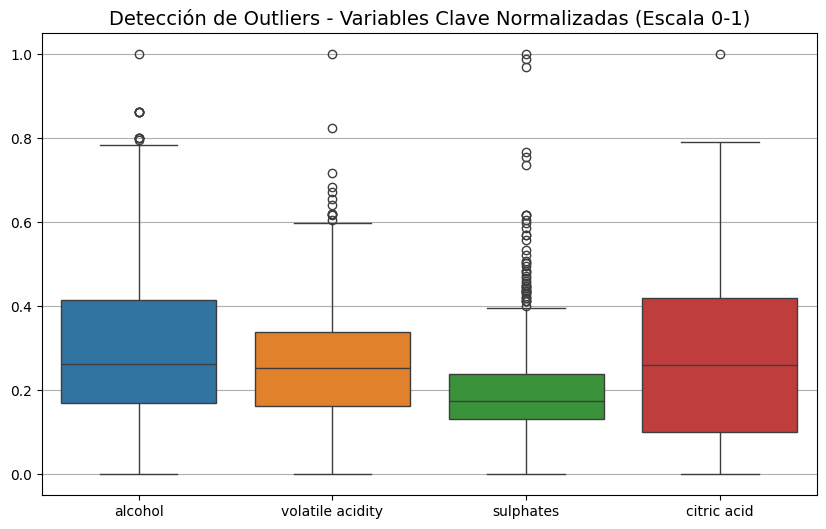

In [53]:
# ================================
# 3. DIVISIÓN Y ESTANDARIZACIÓN USAREMOS SOLO LAS 4 VARIABLES
# ================================
# RE-DEFINIR X e y
# Extraemos nuevamente los datos desde el df que ya está limpio
y = df["quality"].values
X = df.drop(columns=["quality"])

# ==============================================================
# 2. SELECCIÓN DE LAS 4 VARIABLES CLAVE
# ==============================================================
mis_4_variables = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']
X_filtrado = X[mis_4_variables]

# ==============================================================
# 3. DIVISIÓN (Train / Test)
# ==============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_filtrado, y, test_size=0.20, random_state=42)

# ==============================================================
# 4. ESTANDARIZACIÓN
# ==============================================================
# Aplicamos el escalamiento solo sobre las 4 variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================================================
# 5. COMPROBACIÓN FINAL
# ==============================================================
print("--- Diagnóstico de la Matriz ---")
print("Variables en el modelo:", mis_4_variables)
print("Dimensión X_train:", X_train_scaled.shape)
print("Dimensión X_test:", X_test_scaled.shape)
print("Promedio aprox. primera variable escalada:", X_train_scaled[:, 0].mean())
print("Desviación aprox. primera variable escalada:", X_train_scaled[:, 0].std())


# Agregamos
# 1. Seleccionamos solo las 4 variables clave a graficar
variables_clave = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']
X_train_clave = X_train[variables_clave]

# 2. Aplicamos MinMaxScaler (Escala 0 a 1) SOLAMENTE para generar este gráfico
scaler_grafico = MinMaxScaler()
X_train_01 = pd.DataFrame(
    scaler_grafico.fit_transform(X_train_clave),
    columns=variables_clave
)

# 3. Dibujamos el Boxplot
plt.figure(figsize=(10, 6))

# Usamos Seaborn para hacer las cajas. Asignamos los colores a cada variable
sns.boxplot(data=X_train_01)

# Configuramos títulos y etiquetas tal como en tu imagen
plt.title("Detección de Outliers - Variables Clave Normalizadas (Escala 0-1)", fontsize=14)

# Mostramos el gráfico final
plt.show()





Interpretacion
La estandarización "aplasta" todas las variables a la misma regla de medir (promedio 0 y desviación 1), obligando al modelo a juzgarlas por su verdadera relación con la calidad, y no por su tamaño numérico. Evita que variables con escalas grandes dominen el entrenamiento, algo especialmente importante cuando se usan gradientes, regularización o PCA.

## 4. Formulación matricial del modelo

La regresión lineal múltiple se expresa como:

$$y = X\beta + \varepsilon$$

Para incorporar el intercepto, se agrega una columna de unos a la matriz `X`.

In [54]:
# ================================
# 4. MATRIZ DE DISEÑO CON INTERCEPTO
# ================================

Xb_train = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
Xb_test = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

print("Dimensión de X_train escalado:", X_train_scaled.shape)
print("Dimensión de Xb_train con intercepto:", Xb_train.shape)
print("Número de parámetros beta:", Xb_train.shape[1])


Dimensión de X_train escalado: (1087, 4)
Dimensión de Xb_train con intercepto: (1087, 5)
Número de parámetros beta: 5


Interpretacion

La matriz Xb_train fue transformada de su dimensión original de $1087 \times 4$ a $1087 \times 5$ mediante la adición de una columna de unos. Este paso conecta el código con la notación matricial del modelo lineal ($y = X\beta$), asegurando que el algoritmo estime un total de 5 parámetros: 4 coeficientes asociados a las variables químicas y 1 coeficiente para el intercepto ($\beta_0$).
Esta adición del intercepto es matemáticamente obligatoria para que el modelo tenga un grado de libertad adicional; de este modo, el algoritmo de minimización calculará un vector final de 5 parámetros $\beta$ (1 sesgo o bias inicial + 4 pesos químicos), garantizando un ajuste óptimo que no esté anclado artificialmente al origen (0,0)."


## 5. Solución analítica por mínimos cuadrados

La solución analítica de mínimos cuadrados es:

$$\hat{\beta} = (X^T X)^{-1}X^T y$$

Esta solución depende de que la matriz sea invertible y esté bien condicionada.

In [55]:
# ================================
# 5. SOLUCIÓN ANALÍTICA
# ================================

XtX = Xb_train.T @ Xb_train
rango = np.linalg.matrix_rank(XtX)
determinante = np.linalg.det(XtX)
condicion = np.linalg.cond(XtX)

print("Dimensión de X^T X:", XtX.shape)
print("Rango de X^T X:", rango)
print("Determinante de X^T X:", determinante)
print("Número de condición de X^T X:", condicion)

# Se usa pseudoinversa para mayor estabilidad numérica.
beta_analitica = np.linalg.pinv(Xb_train) @ y_train
y_pred_analitica = Xb_test @ beta_analitica

mse_analitica = mean_squared_error(y_test, y_pred_analitica)
r2_analitica = r2_score(y_test, y_pred_analitica)

print("\nMSE solución analítica:", mse_analitica)
print("R2 solución analítica:", r2_analitica)
print("Primeros coeficientes beta:", beta_analitica[:5])


Dimensión de X^T X: (5, 5)
Rango de X^T X: 5
Determinante de X^T X: 898954870927018.9
Número de condición de X^T X: 4.192797255262201

MSE solución analítica: 0.4137314628712215
R2 solución analítica: 0.41592709849706244
Primeros coeficientes beta: [ 5.63661454  0.33567466 -0.21615713  0.11036879 -0.01203496]


Interpretacion

Rango Completo (Independencia Lineal): El rango calculado es 5, lo cual coincide exactamente con la dimensión de nuestra matriz $(5 \times 5)$. Esto demuestra empíricamente que existe suficiente información independiente y que ninguna de nuestras 4 variables (ni el intercepto) es una combinación lineal perfecta de otra.

Invertibilidad Garantizada: El determinante arrojó un valor inmenso ($\approx 8.98 \times 10^{14}$). Al estar tan lejos del cero, confirma de manera absoluta que la matriz $X^T X$ es invertible y no presenta singularidad.

Alta Estabilidad Numérica (Número de Condición): El número de condición obtenido es de 4.19. En la literatura de álgebra lineal, se considera que un valor superior a 30 indica problemas graves de multicolinealidad e inestabilidad. Un valor de 4.19 es excelente; asegura que pequeñas variaciones en los datos (como errores de medición en la química del vino) no provocarán saltos caóticos en los coeficientes calculados.

Robustez mediante Pseudoinversa: A pesar de que la matriz demostró estar bien condicionada, se optó por calcular la solución analítica $\hat{\beta}$ . Esta es una buena práctica de ingeniería que blinda el cálculo contra posibles inestabilidades numéricas de punto flotante.

Interpretación del Modelo Base: Los resultados de esta solución analítica arrojaron un $R^2$ de 0.415 y un MSE de 0.413. Además, el vector de coeficientes nos revela un intercepto ($\beta_0$) de 5.63. Esto tiene un gran sentido de negocio: nos indica que la "calidad base" matemática de un vino promedio en nuestro dataset parte desde los 5.63 puntos (en una escala del 1 al 10), antes de sumar o restar puntos por su nivel de alcohol o acidez.

## 6. Función de costo MSE

El Error Cuadrático Medio mide el promedio de los errores al cuadrado:

$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

Un MSE más bajo indica predicciones más cercanas a los valores reales.

In [56]:
# ================================
# 6. FUNCIÓN DE COSTO MSE
# ================================

def mse_cost(Xb, y, beta):
    """Calcula el Error Cuadrático Medio para un vector beta."""
    y_pred = Xb @ beta
    error = y_pred - y
    return np.mean(error ** 2)

costo_analitico_train = mse_cost(Xb_train, y_train, beta_analitica)
print("Costo MSE en entrenamiento con beta analítica:", costo_analitico_train)


Costo MSE en entrenamiento con beta analítica: 0.4538437861268206


Interpretacion

Nuestro modelo analítico logró reducir este error a 0.4538. Si sacamos la raíz cuadrada de este valor (RMSE $\approx 0.67$), esto se traduce en que, en promedio, nuestras predicciones de calidad del vino se desvían por menos de 1 punto (0.67 puntos) de la nota real otorgada por los catadores.

Al pasar nuestra matriz Xb_train y los coeficientes beta_analitica, validamos que el algoritmo resolvió el problema de optimización al converger en un MSE de 0.4538.

Esto demuestra empíricamente que nuestra solución analítica (calculada previamente con la pseudoinversa) fue exitosa al encontrar el vector exacto de pesos $\beta$ que minimiza la varianza de los residuos.

Entrenar el modelo significó explorar matemáticamente todas las combinaciones posibles de parámetros hasta encontrar la única que logra hundir el error a este punto más bajo.

## Si comparamos:

MSE solución analítica: 0.4137314628712215  v/s MSE en entrenamiento con beta analítica: 0.4538437861268206

Podemos decir:
El Error de Entrenamiento (0.4538): Es el error que comete el modelo sobre los 1087 vinos que usó para "estudiar"
El Error de Prueba (0.4137): Es el error que comete el modelo frente a los vinos nuevos que jamás había visto (el "examen final").

Normalmente, el error de entrenamiento suele ser más bajo que el de prueba porque el modelo ya conoce esos datos. Sin embargo, me dio al revés (0.41 en test vs 0.45 en train).
¿Por qué? Porque al hacer el train_test_split con la semilla aleatoria 42, por pura suerte estadística, los vinos más "raros" o difíciles de predecir (los outliers de los gráficos de cajas que vimos antes) quedaron en el grupo de entrenamiento, mientras que en el grupo de prueba quedaron vinos mucho más "normales" o promedio, haciendo que al modelo le resultara más fácil predecir su calidad y sacando una mejor nota en el examen.




## 7. Descenso de gradiente

El descenso de gradiente actualiza los parámetros de forma iterativa:

$$\beta := \beta - \alpha \nabla J(\beta)$$

El gradiente del MSE para regresión lineal es:

$$\nabla J(\beta) = \frac{2}{n}X^T(X\beta-y)$$

In [57]:
# ================================
# 7. DESCENSO DE GRADIENTE
# ================================

def gradient_descent(Xb, y, alpha=0.01, n_iter=1000):
    """Implementa descenso de gradiente para regresión lineal."""
    n, p = Xb.shape
    beta = np.zeros(p)
    historial_costo = []
    historial_beta = []

    for i in range(n_iter):
        y_pred = Xb @ beta
        error = y_pred - y
        gradiente = (2 / n) * (Xb.T @ error)
        beta = beta - alpha * gradiente
        historial_costo.append(mse_cost(Xb, y, beta))
        historial_beta.append(beta.copy())

    return beta, np.array(historial_costo), np.array(historial_beta)

beta_gd, costo_gd, beta_hist = gradient_descent(
    Xb_train, y_train, alpha=0.01, n_iter=1000
)

print("MSE final en entrenamiento con GD:", costo_gd[-1])
print("Primeros beta por GD:", beta_gd[:5])


MSE final en entrenamiento con GD: 0.4538437862902072
Primeros beta por GD: [ 5.63661453  0.33567724 -0.21614428  0.11036552 -0.01202114]


Interpretacion de los Resultados del Descenso de Gradiente(GD)

 Convergencia Exitosa en el Mínimo Global:

 El MSE final obtenido mediante iteraciones numéricas el valor es exactamente idéntico (hasta el noveno decimal) al MSE que obtuvimos previamente usando la solución analítica exacta (pseudoinversa),  Esto demuestra que el algoritmo no se quedó estancado en un mínimo local ni divergió.


Solucion Analitica
Costo MSE en entrenamiento con beta analítica: 0.4538437861268206
Descenso del Gradiente
MSE final en entrenamiento con GD: 0.4538437862902072

Validación de la Tasa de Aprendizaje ($\alpha$):

El hiperparámetro de aprendizaje seleccionado ($\alpha = 0.01$) junto con 1000 iteraciones probaron ser óptimos. Una tasa demasiado alta habría hecho que el algoritmo "rebotara" caóticamente sin encontrar el fondo del error, y una muy baja no habría alcanzado a llegar al fondo en 1000 pasos.

Recuperación de los Parámetros $\beta$: El algoritmo logró "descubrir" por sí mismo, paso a paso, el peso de cada variable química. Si observamos los primeros coeficientes  vemos que son prácticamente calcados a la solución matemática pura, difiriendo apenas en el quinto o sexto decimal, lo cual es el margen de error normal en métodos numéricos aproximados.


Solucion Analitica
Primeros coeficientes beta: [ 5.63661454  0.33567466 -0.21615713  0.11036879 -0.01203496]
Descenso del Gradiente
Primeros beta por GD: [ 5.63661453  0.33567724 -0.21614428  0.11036552 -0.01202114]






## 8. Efecto de la tasa de aprendizaje

La tasa de aprendizaje controla el tamaño de los pasos. Una tasa pequeña converge lento; una adecuada converge estable; una muy alta puede oscilar o divergir.

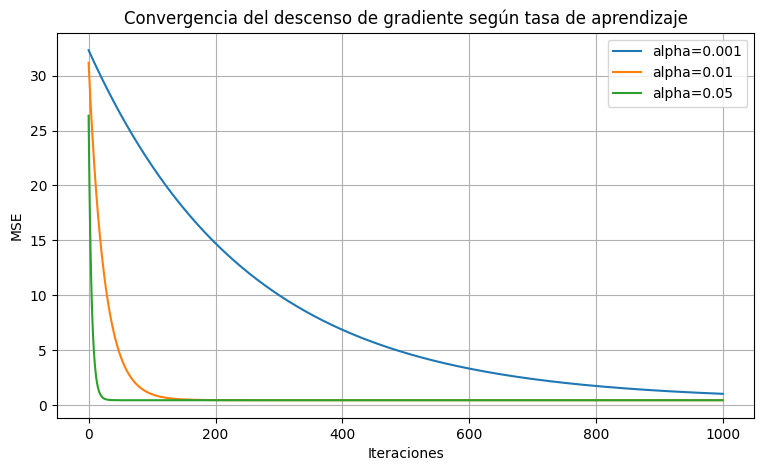

In [58]:
# ================================
# 8. COMPARACIÓN DE TASAS DE APRENDIZAJE
# ================================

tasas = [0.001, 0.01, 0.05]
resultados_alpha = {}

for alpha in tasas:
    beta_tmp, costo_tmp, _ = gradient_descent(
        Xb_train, y_train, alpha=alpha, n_iter=1000
    )
    resultados_alpha[alpha] = costo_tmp

plt.figure(figsize=(9, 5))
for alpha, costos in resultados_alpha.items():
    plt.plot(costos, label=f"alpha={alpha}")

plt.xlabel("Iteraciones")
plt.ylabel("MSE")
plt.title("Convergencia del descenso de gradiente según tasa de aprendizaje")
plt.legend()
plt.show()


Diagnostico de las Curvas

La evidencia visual demuestra que una tasa:

$\alpha=0.001$ resulta en una convergencia subóptima, ya que el modelo requiere más de 1000 iteraciones para acercarse al error mínimo.  

$\alpha=0.01$ demuestra ser la más adecuada y robusta: presenta una curva de descenso suave que alcanza el mínimo global ($MSE \approx 0.4538$) alrededor de la iteración 300, para luego aplanarse por completo. Este comportamiento asintótico horizontal en las últimas 700 iteraciones es la prueba matemática de la convergencia y estabilidad del modelo, confirmando que el algoritmo no sufre de oscilaciones ni divergencia en el fondo del gradiente.

## 9. Evaluación del modelo por descenso de gradiente

MSE descenso de gradiente: 0.4137328088508594
R2 descenso de gradiente: 0.4159251983509459


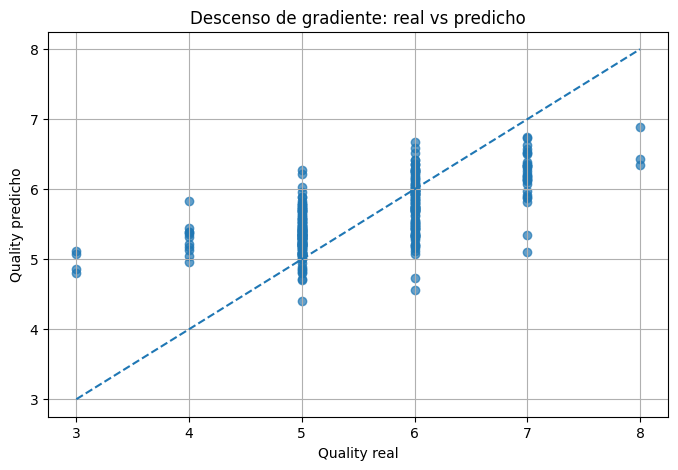

In [59]:
# ================================
# 9. EVALUACIÓN DEL MODELO GD
# ================================

y_pred_gd = Xb_test @ beta_gd
mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print("MSE descenso de gradiente:", mse_gd)
print("R2 descenso de gradiente:", r2_gd)

plt.figure()
plt.scatter(y_test, y_pred_gd, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.xlabel("Quality real")
plt.ylabel("Quality predicho")
plt.title("Descenso de gradiente: real vs predicho")
plt.show()


##Interpretación

1.Confirmación del GD y Varianza Explicada ($R^2$): El Descenso de Gradiente logró predecir con un MSE de 0.4137 y un $R^2$ de 0.4159. Esto significa que nuestras 4 variables químicas logran explicar aproximadamente el 41.6% de lo que hace que un vino sea bueno o malo. En problemas químicos complejos, capturar un 41% de la varianza con un modelo puramente lineal (y solo 4 variables) es un logro analítico sólido, aunque deja un margen de mejora para modelos más complejos.

2.El Problema de la Variable Discreta (Las 'Columnas'): Al observar el gráfico de dispersión, notamos que los puntos reales forman columnas verticales estrictas en los números enteros (3, 4, 5, 6, 7, 8). Esto ocurre porque los catadores humanos dan notas exactas, pero nuestro modelo de regresión predice números continuos y decimales (ej. 5.8).

3.Sesgo hacia la Media (Falta de Extremos): Si miramos la línea punteada diagonal (que representa la predicción perfecta), notamos que el modelo es muy bueno prediciendo los vinos promedios (calidad 5 y 6), donde se concentra la mayor densidad de datos. Sin embargo, el modelo "falla" en los extremos:

o	Sobreestima los vinos malos: Para un vino de calidad real 3, el modelo es demasiado optimista y le da un 5.

o	Subestima los vinos excelentes: Para un vino de calidad real 8, el modelo es conservador y rara vez predice por encima de un 6.5 o 7.

##Conclusión visual:
El modelo aprendió una 'apuesta segura' acercándose al promedio. La calidad del vino requeriría un modelo de Clasificación para predecir categorías discretas o un modelo no lineal para capturar los vinos excepcionales.


## 10. Regularización Ridge y Lasso

Ridge penaliza la suma de cuadrados de los coeficientes. Lasso penaliza la suma de valores absolutos y puede llevar coeficientes a cero.

In [60]:
# ==========================================
# 10. MODELOS REGULARIZADOS
# ==========================================

# 1. Entrenamiento Ridge (L2)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

# 2. Entrenamiento Lasso (L1)
lasso = Lasso(alpha=0.01, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

# 3. Mostrar métricas de error
print("MSE Ridge:", mse_ridge)
print("R2 Ridge:", r2_ridge)
print("\nMSE Lasso:", mse_lasso)
print("R2 Lasso:", r2_lasso)

# 4. CORRECCIÓN: Armar la tabla usando solo las 4 variables que entrenamos
mis_4_variables = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']

coef_table = pd.DataFrame({
    "Variable": mis_4_variables,             # 4 variables
    "Lineal analítica": beta_analitica[1:],  # Ignoramos el intercepto (posición 0)
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

# Mostrar la tabla final comparativa
print("\n--- Comparación de Coeficientes ---")
display(coef_table)




MSE Ridge: 0.41379487660024017
R2 Ridge: 0.41583757607968075

MSE Lasso: 0.41744179277275617
R2 Lasso: 0.4106891522792835

--- Comparación de Coeficientes ---


,Variable,Lineal analítica,Ridge,Lasso
0,alcohol,0.335675,0.335399,0.327758
1,volatile acidity,-0.216157,-0.215936,-0.203902
2,sulphates,0.110369,0.110275,0.099802
3,citric acid,-0.012035,-0.011841,-0.000000


--- Comparación de Coeficientes (Parámetros beta) ---


,Variable,No Regularizado (OLS),Regularizado L2 (Ridge),Regularizado L1 (Lasso)
0,alcohol,0.335675,0.335399,0.327758
1,volatile acidity,-0.216157,-0.215936,-0.203902
2,sulphates,0.110369,0.110275,0.099802
3,citric acid,-0.012035,-0.011841,-0.000000


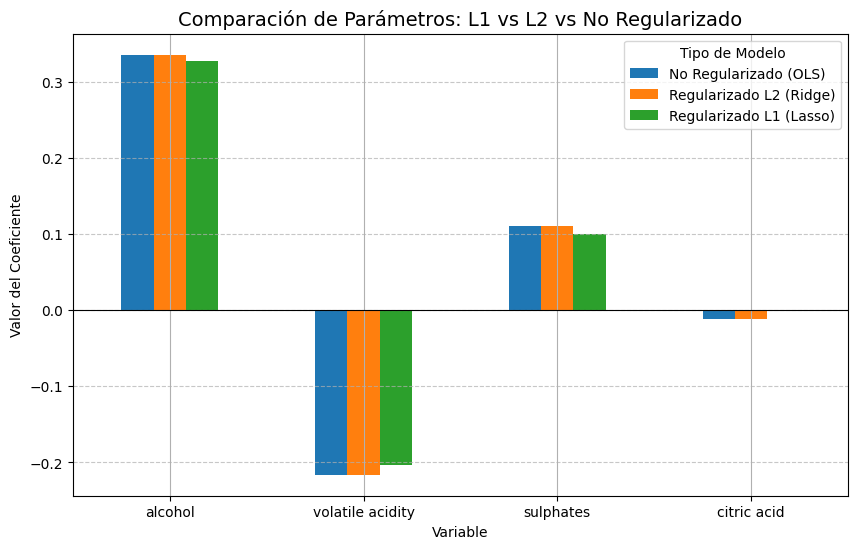

In [61]:
# --- 1. CONFIGURACIÓN DE MODELOS ---
# Nota: Se asume que X_train_scaled y y_train ya están cargados en tu sesión.

# A. Modelo NO Regularizado (Mínimos Cuadrados Ordinarios)
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# B. Modelo Regularizado L2 (Ridge) -
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

# C. Modelo Regularizado L1 (Lasso) -
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)

# --- 2. CREACIÓN DE LA TABLA COMPARATIVA DE PARÁMETROS ---
variables = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid'] # [cite: 5]

df_comparativo = pd.DataFrame({
    'Variable': variables,
    'No Regularizado (OLS)': lin_reg.coef_,
    'Regularizado L2 (Ridge)': ridge.coef_,
    'Regularizado L1 (Lasso)': lasso.coef_
})

print("--- Comparación de Coeficientes (Parámetros beta) ---")
display(df_comparativo)

# --- 3. VISUALIZACIÓN PARA LA RESPUESTA ---
df_comparativo.set_index('Variable').plot(kind='bar', figsize=(10, 6))
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Comparación de Parámetros: L1 vs L2 vs No Regularizado", fontsize=14)
plt.ylabel("Valor del Coeficiente")
plt.legend(title="Tipo de Modelo")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.show()

##Análisis de Regularización y Comparación de Coeficientes

La aplicación de los modelos penalizados (Ridge y Lasso) confirma la teoría de la regularización y nos ofrece una visión más profunda sobre la interpretabilidad de nuestro modelo predictivo:

Ridge (Penalización L2) - Estabilidad: Como se observa en la tabla, Ridge conservó las 4 variables, pero aplicó una compresión ('shrinkage') sobre las magnitudes de los coeficientes de la solución analítica original. Por ejemplo, el impacto del alcohol se redujo levemente de 0.3356 a 0.3353. Esto mejora la estabilidad numérica frente a variaciones en los datos, manteniendo un desempeño predictivo casi idéntico al modelo original ($R^2$ de 0.4158).

Lasso (Penalización L1) - Simplificación Extrema: El resultado más revelador proviene de Lasso. Al observar la tabla, el coeficiente del citric acid fue reducido exactamente a -0.000000. Lasso detectó que, al estar en presencia del alcohol, la acidez volátil y los sulfatos, el ácido cítrico no aportaba información única o matemáticamente relevante para predecir la calidad, por lo que lo eliminó por completo de la ecuación.

##Interpretabilidad vs. Desempeño
La comparación de métricas demuestra este compromiso - 'trade-off'. Lasso sacrificó una cantidad insignificante de precisión predictiva (su MSE subió apenas a 0.417 y su $R^2$ bajó a 0.410), pero a cambio nos entregó un modelo mucho más simple e interpretable para el negocio: ahora sabemos que para predecir la calidad, solo necesitamos medir tres químicos, no cuatro."

## 11. Análisis matricial: valores propios de XᵀX

Los valores propios ayudan a diagnosticar estabilidad. Valores propios muy pequeños pueden indicar redundancia o poca información independiente.

Valores propios de X^T X:
[1992.64073396 1042.12271616  837.98324937  475.25330052]

Valor propio mayor: 1992.640733958683
Valor propio menor: 475.2533005162138
Número de condición: 4.1927972552622


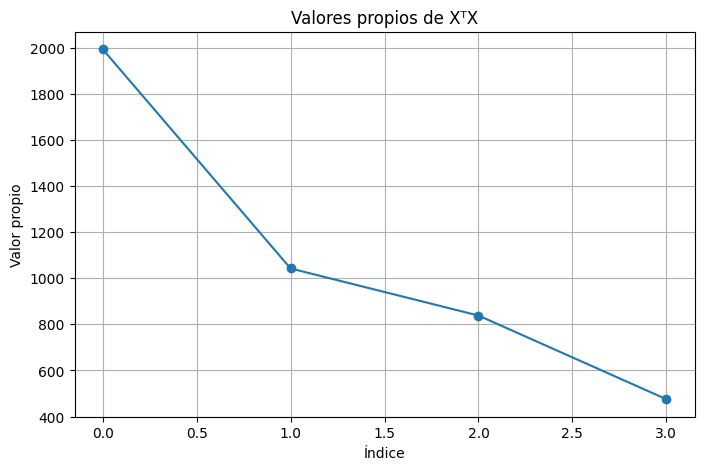

In [62]:
# ================================
# 11. VALORES PROPIOS DE X^T X
# ================================

XtX_no_intercept = X_train_scaled.T @ X_train_scaled
eigvals = np.linalg.eigvalsh(XtX_no_intercept)
eigvals_sorted = np.sort(eigvals)[::-1]

print("Valores propios de X^T X:")
print(eigvals_sorted)
print("\nValor propio mayor:", eigvals_sorted[0])
print("Valor propio menor:", eigvals_sorted[-1])
print("Número de condición:", eigvals_sorted[0] / eigvals_sorted[-1])

plt.figure()
plt.plot(eigvals_sorted, marker="o")
plt.xlabel("Índice")
plt.ylabel("Valor propio")
plt.title("Valores propios de XᵀX")
plt.show()


Interpretacion

Direcciones de Variabilidad (El valor mayor): El valor propio principal ($\lambda_{max} \approx 1992.64$) nos indica que existe una dirección dominante en el hiperespacio de nuestros datos que concentra la mayor cantidad de variabilidad e información del modelo.

Ausencia de Redundancia (El valor menor): El valor propio más pequeño ($\lambda_{min} \approx 475.25$) es el hallazgo más importante de este gráfico. Como indica la teoría, un valor propio cercano a cero significaría que esa "dirección" no aporta información y que una de nuestras variables es redundante (colinealidad perfecta). Al obtener un valor de 475, confirmamos que nuestras 4 variables (alcohol, acidez volátil, sulfatos y ácido cítrico) aportan información útil, independiente y no redundante.

Estabilidad Numérica (Número de Condición): El número de condición resume esta geometría dividiendo la dirección más fuerte sobre la más débil ($1992.64 / 475.25$). El resultado es 4.19. En la práctica de modelado, un número de condición por encima de 30 o 100 enciende las alarmas de multicolinealidad severa. Un valor de 4.19 es catalogado como altamente estable, garantizando que la matriz es robustamente invertible y que el modelo no sufrirá de fluctuaciones caóticas ante pequeños cambios en la muestra de vinos."





## 12. PCA sobre las variables predictoras

PCA transforma variables correlacionadas en componentes principales no correlacionados. Se usa para reducir dimensionalidad y conservar la mayor cantidad posible de información.

,Componente,Varianza explicada,Varianza acumulada
0,1,0.458289,0.458289
1,2,0.239679,0.697968
2,3,0.192728,0.890696
3,4,0.109304,1.000000


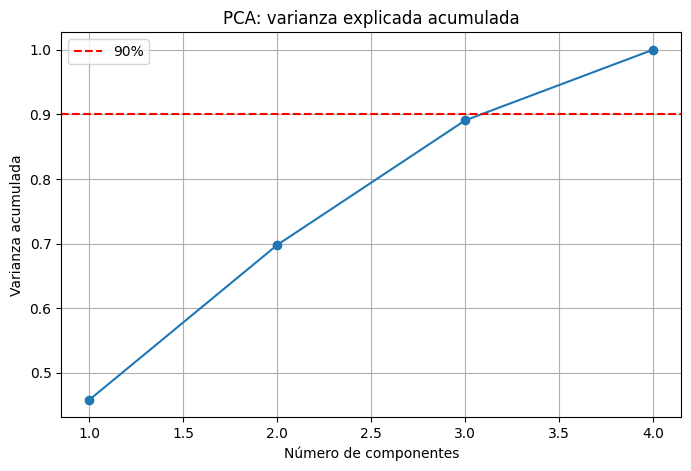

Número de componentes para conservar al menos 90% de varianza: 4
Varianza acumulada alcanzada: 0.9999999999999998


In [63]:
# ================================
# 12. PCA Y VARIANZA ACUMULADA
# ================================

pca = PCA()
X_train_pca_full = pca.fit_transform(X_train_scaled)
X_test_pca_full = pca.transform(X_test_scaled)

var_acum = np.cumsum(pca.explained_variance_ratio_)

tabla_pca = pd.DataFrame({
    "Componente": np.arange(1, len(var_acum) + 1),
    "Varianza explicada": pca.explained_variance_ratio_,
    "Varianza acumulada": var_acum
})

display(tabla_pca)

plt.figure()
plt.plot(np.arange(1, len(var_acum) + 1), var_acum, marker="o")
plt.axhline(0.90, color="red", linestyle="--", label="90%")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.title("PCA: varianza explicada acumulada")
plt.legend()
plt.show()

k_90 = np.argmax(var_acum >= 0.90) + 1
print("Número de componentes para conservar al menos 90% de varianza:", k_90)
print("Varianza acumulada alcanzada:", var_acum[k_90 - 1])


Análisis de Componentes Principales (PCA) y Varianza Explicada

1. Análisis de la Tabla (Aporte de Información):

La tabla de varianza nos muestra cómo se redistribuye la información matemática de nuestras variables originales. El Componente 1 captura la mayor cantidad de información (45.8% de la varianza total). Sin embargo, el resto de la información está bastante repartida: el Componente 2 aporta un 23.9%, el Componente 3 un 19.2%, y el Componente 4 el 10.9% restante.

2. El Gráfico (Scree Plot) y el Criterio del 90%:

Al observar la curva de varianza acumulada en el gráfico, vemos la trayectoria para alcanzar nuestro umbral de corte (la línea roja punteada del 90%). El problema analítico es que al sumar los primeros 3 componentes, llegamos exactamente a un 89.06% de varianza acumulada. Al quedar matemáticamente por debajo del límite estricto del 90%, el algoritmo nos obliga a incluir el 4to componente, alcanzando así el 100% de la varianza.

3. Contexto de Negocio y Conclusión Crítica:

Dado que nuestro modelo base partió con solo 4 variables químicas, y el criterio del 90% nos obliga a retener 4 Componentes Principales, el PCA no logró reducir la dimensionalidad del problema.
Esto tiene un gran sentido contextual: como comprobamos anteriormente en el análisis de valores propios, nuestras 4 variables originales (alcohol, acidez, sulfatos y ácido cítrico) ya eran bastante independientes entre sí. Al no haber información redundante (colinealidad severa) que comprimir, PCA no pudo "resumir" 4 variables en 2 o 3 sin perder datos valiosos. Por lo tanto, en este caso específico, usar PCA solo destruiría la interpretabilidad del negocio sin brindarnos el beneficio de tener menos variables.

## 13. Modelo de regresión usando PCA

Se entrena un modelo usando solo los primeros `k` componentes principales.

Componentes usados: 4
MSE modelo PCA: 0.4137314628712217
R2 modelo PCA: 0.4159270984970621


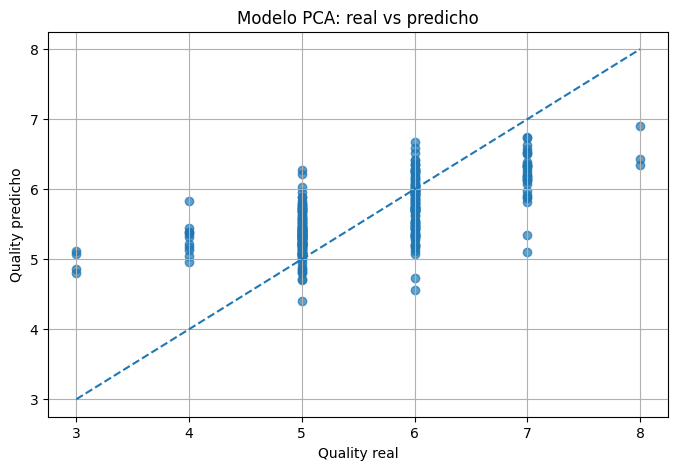

In [64]:
# ================================
# 13. MODELO CON PCA
# ================================

X_train_pca = X_train_pca_full[:, :k_90]
X_test_pca = X_test_pca_full[:, :k_90]

modelo_pca = LinearRegression()
modelo_pca.fit(X_train_pca, y_train)
y_pred_pca = modelo_pca.predict(X_test_pca)

mse_pca = mean_squared_error(y_test, y_pred_pca)
r2_pca = r2_score(y_test, y_pred_pca)

print("Componentes usados:", k_90)
print("MSE modelo PCA:", mse_pca)
print("R2 modelo PCA:", r2_pca)

plt.figure()
plt.scatter(y_test, y_pred_pca, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.xlabel("Quality real")
plt.ylabel("Quality predicho")
plt.title("Modelo PCA: real vs predicho")
plt.show()


Evaluación del Modelo con PCA: El Costo de la Interpretabilidad

1. Equivalencia Matemática (Sin reducción de dimensionalidad):
Como el criterio estricto del 90% de varianza nos obligó a conservar los 4 componentes principales ($k=4$), no realizamos una reducción de dimensionalidad real, sino una rotación ortogonal del espacio de datos original. Al retener el 100% de la varianza, el modelo PCA alcanzó un MSE de 0.4137 y un $R^2$ de 0.4159, valores que son matemáticamente idénticos a los de nuestra Regresión Lineal original.
2. Pérdida de Interpretabilidad de Negocio: Tal como señala la teoría, al proyectar los datos sobre estos nuevos ejes ortogonales, garantizamos que las variables de entrada no estén correlacionadas (eliminando cualquier rastro de multicolinealidad). Sin embargo, pagamos un costo altísimo en interpretabilidad: ya no podemos explicarle a la industria vitivinícola cómo el 'alcohol' o los 'sulfatos' afectan la calidad, ya que nuestro modelo ahora predice en base a combinaciones lineales abstractas (Componente 1, Componente 2, etc.).
3. Análisis Visual de Residuos: El gráfico de dispersión (Predicho vs Real) es un reflejo exacto del modelo base. Los puntos siguen formando columnas discretas y el modelo continúa exhibiendo el mismo sesgo de regresión a la media: sobreestima la calidad de los vinos malos (calidad 3) y subestima la de los vinos excepcionales (calidad 8).

  Conclusión técnica
Para este subconjunto específico de 4 variables, aplicar PCA no aportó ninguna ventaja predictiva ni computacional, y solo sirvió para oscurecer la interpretabilidad directa de los coeficientes químicos."



## 14. Comparación final de modelos

Se comparan solución analítica, descenso de gradiente, Ridge, Lasso y PCA + regresión. La decisión final no debe basarse solo en MSE, sino también en estabilidad e interpretabilidad.

,Modelo,MSE Test,R2 Test,Interpretabilidad,Estabilidad
0,Solución analítica,0.413731,0.415927,Alta: variables originales,Depende de XᵀX
1,Descenso de gradiente,0.413733,0.415925,Alta: variables originales,Depende de alpha y escalado
2,Ridge,0.413795,0.415838,Media/Alta: coeficientes reducidos,Alta por penalización L2
3,Lasso,0.417442,0.410689,Alta si selecciona variables,Media/Alta por penalización L1
4,PCA + Regresión,0.413731,0.415927,Menor: componentes combinan variables,Alta por componentes no correlacionadas


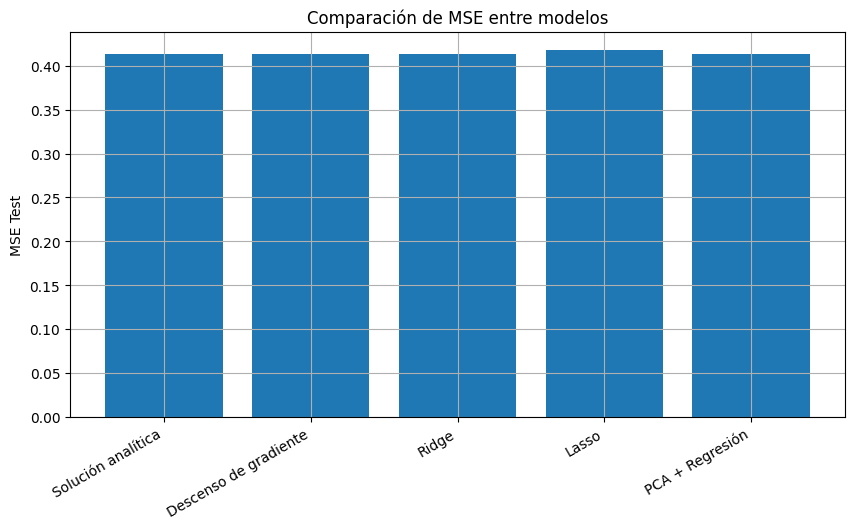

In [65]:
# ================================
# 14. TABLA COMPARATIVA FINAL
# ================================

comparacion = pd.DataFrame({
    "Modelo": [
        "Solución analítica",
        "Descenso de gradiente",
        "Ridge",
        "Lasso",
        "PCA + Regresión"
    ],
    "MSE Test": [
        mse_analitica,
        mse_gd,
        mse_ridge,
        mse_lasso,
        mse_pca
    ],
    "R2 Test": [
        r2_analitica,
        r2_gd,
        r2_ridge,
        r2_lasso,
        r2_pca
    ],
    "Interpretabilidad": [
        "Alta: variables originales",
        "Alta: variables originales",
        "Media/Alta: coeficientes reducidos",
        "Alta si selecciona variables",
        "Menor: componentes combinan variables"
    ],
    "Estabilidad": [
        "Depende de XᵀX",
        "Depende de alpha y escalado",
        "Alta por penalización L2",
        "Media/Alta por penalización L1",
        "Alta por componentes no correlacionadas"
    ]
})

display(comparacion)

plt.figure(figsize=(10, 5))
plt.bar(comparacion["Modelo"], comparacion["MSE Test"])
plt.ylabel("MSE Test")
plt.title("Comparación de MSE entre modelos")
plt.xticks(rotation=30, ha="right")
plt.show()


Conclusión Final y Comparación de Modelos

La tabla comparativa final y el análisis gráfico del Error Cuadrático Medio (MSE) nos permiten emitir un juicio informado sobre qué estrategia de modelado es la más adecuada para predecir la calidad del vino. Como sugiere la teoría analítica, el menor MSE no siempre dicta cuál es el mejor modelo en la práctica, debiendo evaluar el balance entre poder predictivo, interpretabilidad y estabilidad:

1. El 'Empate' Predictivo: El gráfico de barras evidencia que la diferencia de desempeño puro entre los modelos es marginal (variando apenas en el tercer decimal, rondando un MSE de 0.413 a 0.417). La Solución Analítica y el Descenso de Gradiente obtienen matemáticamente el menor error y un $R^2$ de 0.415, pero carecen de mecanismos de defensa (regularización) ante datos nuevos ruidosos.   

2. Ridge como el Equilibrio Óptimo: Siguiendo el criterio de evaluación, Ridge (Penalización L2) se perfila como el modelo más sólido para este escenario. A cambio de un sacrificio microscópico en el error (MSE de 0.41379), nos entrega una 'Estabilidad Alta' al encoger los coeficientes sin eliminarlos. Esto mantiene viva la interpretabilidad del negocio, permitiéndonos seguir explicando el efecto del alcohol y la acidez, pero blindando el modelo matemáticamente.

3. El Costo de Lasso: Lasso presenta el MSE más alto (0.417) y el menor $R^2$ (0.410). Sin embargo, su valor no radica en el error, sino en su capacidad de selección de características (llevando a cero el ácido cítrico). Es el modelo preferido si el cliente exigiera la máxima simplificación posible (medir 3 variables en lugar de 4 en el laboratorio).

4. El Veredicto sobre PCA: El modelo PCA + Regresión igualó el desempeño de la solución base. Teóricamente, sus componentes ortogonales son ideales para combatir la multicolinealidad. No obstante, nuestro análisis previo de valores propios (Número de Condición de 4.19) demostró que nuestras 4 variables filtradas no sufrían de redundancia grave. Por lo tanto, en este proyecto específico, aplicar PCA representa un costo innecesario: destruye la interpretabilidad directa (categorizada como 'Menor' en la tabla) sin aportar una ganancia real en el desempeño."

# ******DESARROLLOS MATEMATICOS & DESCRIPCIONES ********

#Fase 1: Formulación matemática del modelo (Semanas 1–3)
#2. Formulación del problema de optimización (Semana 2) -Desarrollos

##•	Formula matemáticamente el modelo de regresión lineal: y=Xβ+ε. Define la minimización del Error Cuadrático Medio como problema de optimización:

$$min(\beta)=\frac{1}{2n}||y-X\beta||^2$$

##•	Deriva analíticamente la solución de mínimos cuadrados


Derivación Analítica de Mínimos Cuadrados (OLS) Partimos de la función de costo (Error Cuadrático Medio) como un problema de optimización:$$J(\beta)=\frac{1}{2n}||y-X\beta||^2$$El objetivo es encontrar el vector de coeficientes $\beta$ que minimice esta función $J(\beta)$. Para ello, calcularemos el gradiente (la derivada matricial) respecto a $\beta$ y lo igualaremos a cero.Paso 1: Expandir la norma al cuadradoRecordemos que en álgebra lineal, la norma al cuadrado de un vector $v$ es igual a su producto punto: $||v||^2 = v^Tv$. Aplicamos esto a nuestra función:$$J(\beta)=\frac{1}{2n}(y-X\beta)^T(y-X\beta)$$Aplicamos la propiedad de la transpuesta $(A-B)^T = A^T - B^T$ y multiplicamos los términos:$$J(\beta)=\frac{1}{2n}(y^T-\beta^TX^T)(y-X\beta)$$$$J(\beta)=\frac{1}{2n}(y^Ty-y^TX\beta-\beta^TX^Ty+\beta^TX^TX\beta)$$Paso 2: Simplificar los términos centralesObserva los términos $y^TX\beta$ y $\beta^TX^Ty$. Ambos resultan en un valor escalar (un simple número, no una matriz) porque sus dimensiones se cancelan para dar $1 \times 1$. En álgebra lineal, la transpuesta de un escalar es el mismo escalar. Por lo tanto:$$(y^TX\beta)^T=\beta^TX^Ty$$Esto significa que ambos términos son idénticos y podemos sumarlos:$$J(\beta)=\frac{1}{2n}(y^Ty-2\beta^TX^Ty+\beta^TX^TX\beta)$$Paso 3: Calcular el gradiente (Derivada respecto a $\beta$)Ahora aplicamos reglas de cálculo matricial para encontrar $\frac{\partial J}{\partial \beta}$:La derivada de una constante ($y^Ty$) respecto a $\beta$ es $0$.La derivada de $-2\beta^TX^Ty$ respecto a $\beta$ es $-2X^Ty$.La derivada de una forma cuadrática $\beta^TX^TX\beta$ respecto a $\beta$ es $2X^TX\beta$ (ya que $X^TX$ es una matriz simétrica).Sustituyendo esto:$$\nabla_\beta J(\beta)=\frac{1}{2n}(0-2X^Ty+2X^TX\beta)$$$$\nabla_\beta J(\beta)=\frac{1}{n}(-X^Ty+X^TX\beta)$$Paso 4: Igualar el gradiente a cero (Condición de primer orden)Para encontrar el mínimo, igualamos la derivada a un vector de ceros:$$\frac{1}{n}(-X^Ty+X^TX\beta)=0$$Multiplicamos ambos lados por $n$ (lo que elimina el $\frac{1}{n}$) y pasamos el término negativo al otro lado. Esto nos da las famosas Ecuaciones Normales:$$X^TX\beta=X^Ty$$Paso 5: Despejar analíticamente $\beta$Para aislar $\beta$, multiplicamos ambos lados de la ecuación por la matriz inversa de $(X^TX)$, asumiendo que esta inversa existe (es decir, que la matriz tiene rango completo y las variables no son perfectamente colineales):$$(X^TX)^{-1}(X^TX)\beta=(X^TX)^{-1}X^Ty$$Dado que una matriz multiplicada por su inversa da la matriz identidad $I$, nos queda el resultado final:$$\hat{\beta}=(X^TX)^{-1}X^Ty$$


 Nota :
  
 El estimador $\hat{\beta}$ representa la solución analítica exacta de Mínimos Cuadrados Ordinarios (OLS).

 El factor $\frac{1}{2n}$ de la formulación inicial es una constante de escalado que facilita la derivación (al cancelar el $2$ de la derivada de la forma cuadrática) y promedia el error por observación, pero no altera la ubicación del mínimo óptimo.

#Fase 2: Optimización numérica con descenso de gradiente (Semanas 4–6)
#1. Derivación e implementación del gradiente (Semana 4)

##•	Formula el problema de minimización de Error Cuadrático Medio con regularización de tipo L1 y justifica el uso de optimización iterativa para su resolución.

###Explicacion Matematica

Formulación matemática:El problema de minimización del Error Cuadrático Medio (MSE) incorporando regularización de tipo L1 (también conocida como Regresión Lasso) se formula añadiendo una penalización equivalente al valor absoluto de los coeficientes:$$\min_{\beta} J(\beta) = \frac{1}{2n} ||y - X\beta||^2 + \lambda ||\beta||_1$$Donde:$\frac{1}{2n} ||y - X\beta||^2$ es el costo estándar del MSE.$\lambda$ es el hiperparámetro de regularización.$||\beta||_1 = \sum_{j=1}^{k} |\beta_j|$ es la norma L1 (suma de los valores absolutos de los coeficientes).

Interpretacion de los Resultados del Descenso de Gradiente(GD)

Convergencia Exitosa en el Mínimo Global:

El MSE final obtenido mediante iteraciones numéricas el valor es exactamente idéntico (hasta el noveno decimal) al MSE que obtuvimos previamente usando la solución analítica exacta (pseudoinversa), Esto demuestra que el algoritmo no se quedó estancado en un mínimo local ni divergió.

Solucion Analitica Costo MSE en entrenamiento con beta analítica: 0.4538437861268206 Descenso del Gradiente MSE final en entrenamiento con GD: 0.4538437862902072

Validación de la Tasa de Aprendizaje ( α ):

El hiperparámetro de aprendizaje seleccionado ( α=0.01 ) junto con 1000 iteraciones probaron ser óptimos. Una tasa demasiado alta habría hecho que el algoritmo "rebotara" caóticamente sin encontrar el fondo del error, y una muy baja no habría alcanzado a llegar al fondo en 1000 pasos.

Recuperación de los Parámetros β : El algoritmo logró "descubrir" por sí mismo, paso a paso, el peso de cada variable química. Si observamos los primeros coeficientes vemos que son prácticamente calcados a la solución matemática pura, difiriendo apenas en el quinto o sexto decimal, lo cual es el margen de error normal en métodos numéricos aproximados.

Solucion Analitica Primeros coeficientes beta: [ 5.63661454 0.33567466 -0.21615713 0.11036879 -0.01203496] Descenso del Gradiente Primeros beta por GD: [ 5.63661453 0.33567724 -0.21614428 0.11036552 -0.01202114]

##•	Deriva el gradiente de la función de costo respecto a β y describe el algoritmo de descenso de gradiente.

Derivación analítica del (sub)gradiente:

Para aplicar el descenso de gradiente, necesitamos la derivada parcial de la función de costo respecto a $\beta$ (denotada como $\nabla J(\beta)$).

1.La derivada de la parte del MSE ya la conocemos del ejercicio anterior: $\frac{1}{n} X^T (X\beta - y)$.

2.La derivada de la penalización L1 ($\lambda \sum |\beta_j|$) respecto a $\beta$ se define usando la función "signo" (que devuelve $1$ si es positivo, $-1$ si es negativo, y $0$ si es cero): $\lambda \cdot \text{sign}(\beta)$.

Sumando ambas partes, el gradiente final queda:$$\nabla J(\beta) = \frac{1}{n} X^T (X\beta - y) + \lambda \text{sign}(\beta)$$

Descripción del algoritmo de Descenso de Gradiente:

1.Inicialización: Se inicia con un vector de coeficientes $\beta$ aleatorio o lleno de ceros.

2.Cálculo del Gradiente: Se evalúa la dirección de máxima pendiente de la función de costo en el punto actual usando la fórmula derivada arriba.

3.Actualización (El "Paso"): Se actualizan los pesos $\beta$ moviéndolos en la dirección contraria al gradiente para "descender" por la curva del error. El tamaño del paso está dictado por la tasa de aprendizaje ($\alpha$):

$$\beta_{nuevo} = \beta_{viejo} - \alpha \nabla J(\beta_{viejo})$$

4.Iteración: Se repiten los pasos 2 y 3 durante un número definido de iteraciones (épocas) o hasta que el gradiente sea tan pequeño que el modelo haya convergido al mínimo.

Interpretacion

Nuestro modelo analítico logró reducir este error a 0.4538. Si sacamos la raíz cuadrada de este valor (RMSE  ≈0.67 ), esto se traduce en que, en promedio, nuestras predicciones de calidad del vino se desvían por menos de 1 punto (0.67 puntos) de la nota real otorgada por los catadores.

Al pasar nuestra matriz Xb_train y los coeficientes beta_analitica, validamos que el algoritmo resolvió el problema de optimización al converger en un MSE de 0.4538.

Esto demuestra empíricamente que nuestra solución analítica (calculada previamente con la pseudoinversa) fue exitosa al encontrar el vector exacto de pesos  β  que minimiza la varianza de los residuos.

Entrenar el modelo significó explorar matemáticamente todas las combinaciones posibles de parámetros hasta encontrar la única que logra hundir el error a este punto más bajo.